# AI Lab Assignment: Clustering & Classification Techniques

**Objective**: In this lab, you will explore both unsupervised and supervised clustering techniques using the same IMDb Top 1000 Movies dataset. You'll apply **K-Means
Clustering** to uncover hidden patterns and **Logistic Regression** to perform classification based on a labeled target.

Let us import some necessary libraries first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Let us load our "imdb_top_1000_processed.csv" file in a dataset and see the first 10 rows of our dataset.

In [2]:
df = pd.read_csv("imdb_top_1000_processed.csv")

df.head(10)

,Series_Title,Overview,Director,Star1,Star2,Star3,Star4,Released_Year,Certificate,Runtime,...,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count
0,12 Angry Men,A jury holdout attempts to prevent a miscarria...,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,-1.614583,-0.716326,-0.985624,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
1,"Il buono, il brutto, il cattivo",A bounty hunting scam joins two men in an unea...,Sergio Leone,Clint Eastwood,Eli Wallach,Lee Van Cleef,Aldo Giuffr,-1.203222,1.735177,1.412753,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818
2,Gisaengchung,Greed and class discrimination threaten the ne...,Bong Joon Ho,Kang-ho Song,Lee Sun-kyun,Cho Yeo-jeong,Choi Woo-sik,1.219236,1.735177,0.342708,...,-0.345033,-0.406558,-0.235349,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721
3,Cidade de Deus,"In the slums of Rio, two kids' paths diverge a...",Fernando Meirelles,Ktia Lund,Alexandre Rodrigues,Leandro Firmino,Matheus Nachtergaele,0.442221,1.735177,0.268911,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048
4,Sen to Chihiro no kamikakushi,"During her family's move to the suburbs, a sul...",Hayao Miyazaki,Daveigh Chase,Suzanne Pleshette,Miyu Irino,Rumi Hiiragi,0.396514,-0.716326,0.084421,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721
5,La vita  bella,When an open-minded Jewish librarian and his s...,Roberto Benigni,Roberto Benigni,Nicoletta Braschi,Giorgio Cantarini,Giustino Durano,0.213687,-0.716326,-0.247662,...,-0.345033,2.459675,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,0.738721
6,Shichinin no samurai,A poor village under attack by bandits recruit...,Akira Kurosawa,Toshir Mifune,Takashi Shimura,Keiko Tsushima,Yukiko Shimazaki,-1.751703,-0.716326,3.110066,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721
7,Whiplash,A promising young drummer enrolls at a cut-thr...,Damien Chazelle,Miles Teller,J.K. Simmons,Melissa Benoist,Paul Reiser,0.990702,1.735177,-0.616643,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
8,The Intouchables,After he becomes a quadriplegic from a paragli...,Olivier Nakache,ric Toledano,Franois Cluzet,Omar Sy,Anne Le Ny,0.853582,0.509426,-0.395255,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,0.738721
9,The Pianist,A Polish Jewish musician struggles to survive ...,Roman Polanski,Adrien Brody,Thomas Kretschmann,Frank Finlay,Emilia Fox,0.442221,-0.716326,1.006873,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721


We only work with numerical features, so we can drop all the others and keep a dataset copy.

In [3]:
df_numerical = df.copy()

df_numerical.drop(columns=["Series_Title","Overview","Director","Star1","Star2","Star3","Star4"], inplace=True)

In [4]:
df_numerical.head(10)

,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,Adventure,Animation,...,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count
0,-1.614583,-0.716326,-0.985624,4.592377,1.543382,2.463019,-0.672064,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
1,-1.203222,1.735177,1.412753,3.750561,1.043190,2.455505,-0.632888,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818
2,1.219236,1.735177,0.342708,2.908744,1.543382,1.755130,0.431357,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721
3,0.442221,1.735177,0.268911,2.908744,0.126171,2.511623,-0.599939,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048
4,0.396514,-0.716326,0.084421,2.908744,1.543382,2.264344,-0.543821,-0.415987,2.488750,3.923691,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721
5,0.213687,-0.716326,-0.247662,2.908744,-1.541135,2.121044,0.526605,-0.415987,-0.401808,-0.254862,...,-0.345033,2.459675,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,0.738721
6,-1.751703,-0.716326,3.110066,2.908744,1.710112,0.530956,-0.764172,2.403923,2.488750,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721
7,0.990702,1.735177,-0.616643,2.487836,0.876459,2.606284,-0.475461,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
8,0.853582,0.509426,-0.395255,2.487836,-1.707866,2.827198,-0.473429,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,0.738721
9,0.442221,-0.716326,1.006873,2.487836,0.626363,2.668352,-0.036852,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721


Now we have the dataset completely cleaned up and ready to work with.

## Part 1: Clustering with K-Means (Unsupervised Learning)

Choose relevant numerical features (after preprocessing and normalization) to cluster movies using K-Means. You may need to engineer or reduce features for better
clustering.

## K-Means Clustering Concepts

### Elbow Method:
The Elbow Method is used to find the optimal number of clusters (k) in K-Means by plotting the within-cluster sum of squares (inertia) against k. The 'elbow point' is where the rate of decrease sharply slows, indicating diminishing returns for adding more clusters.

### Inertia:
Inertia measures the compactness of the clusters. It is defined as the sum of squared distances between each point and its assigned cluster centroid.

$$ \text{Inertia} = \sum_{i=1}^{k} \sum_{x_j \in C_i} \| x_j - \mu_i \|^2 $$

Where:
- \( k \): number of clusters
- \( x_j \): data point assigned to cluster \( C_i \)
- \( \mu_i \): centroid of cluster \( C_i \)

Lower inertia means tighter clusters.

### Silhouette Score:
The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters. Values range from -1 to 1:
- **1**: Perfectly matched to its own cluster and well-separated from others.
- **0**: On or very close to the decision boundary between two clusters.
- **-1**: Incorrectly assigned to the wrong cluster.

Higher silhouette scores indicate better-defined clusters.
"""

**Steps to follow:**

- Analyze clustering by group of "logical" features:
   - by financial metrics (e.g., gross, budget, runtime).
   - by quality metrics (e.g., IMDB rating, Meta score).
   - by popularity + genre (requires encoding categorical variables).
   - or others based on previous analysis
- Preprocess data: handle missing values, normalize features. (already done in the preprocessing part, see Movie-Recommendation-System project)
- Use the Elbow Method and Silhouette Score to determine the optimal number of clusters (k).
- Fit the K-Means algorithm and label each movie with its cluster.
- Visualize the clusters in 2D using dimensionality reduction.
- Interpret cluster profiles: what makes each group of movies unique?

Let us cluster by grouping:

In [5]:
print("Dataset Overview:")
print(df_numerical.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Released_Year  705 non-null    float64
 1   Certificate    705 non-null    float64
 2   Runtime        705 non-null    float64
 3   IMDB_Rating    705 non-null    float64
 4   Meta_score     705 non-null    float64
 5   No_of_Votes    705 non-null    float64
 6   Gross          705 non-null    float64
 7   Action         705 non-null    float64
 8   Adventure      705 non-null    float64
 9   Animation      705 non-null    float64
 10  Biography      705 non-null    float64
 11  Comedy         705 non-null    float64
 12  Crime          705 non-null    float64
 13  Drama          705 non-null    float64
 14  Family         705 non-null    float64
 15  Fantasy        705 non-null    float64
 16  History        705 non-null    float64
 17  Horror         705 non-null    float

In [6]:
df_financial = df_numerical[["Gross","Runtime","Is_Short_Film"]]
df_quality = df_numerical[["IMDB_Rating","Meta_score"]]
df_popularity_genre=df_numerical[["No_of_Votes",
                     "Action", "Adventure", "Animation", "Biography", "Comedy", "Crime", "Drama",
                    "Family", "Fantasy", "History", "Horror", "Music", "Mystery", "Romance",
                    "Sci-Fi", "Sport", "Thriller", "War", "Western"]]
df_certificate_year=df_numerical[["Certificate","Released_Year"]]


The reasoning behind this is that :
- **Gross** is clearly related to financial aspects, bigger **Runtime** means higher financial profits + from the preprocessing part, **Is_Short_Film** is highly correlated to Runtime(correlation matrix and feature engineering);
- high ratings give a better quality of the movies
- all the encoded values of **Genre** can make a video less or more popular and influence the type of the movie + **No_of_Votes** clearly gives the popularity
- **Certificate,Released_Year** are correlated, from the data processing part, because most of the certificates of type 1 are released more recently.

The genres probably will give us more clusters, because they are many and we can not really see the reasoning behind them.

Some useful notions:
- centroids: the mean of all points in a cluster.
- inertia : total sum of squared distances from each point to its assigned centroid

## Elbow Method

Plot the number of clusters vs. loss (inertia) and look for an "elbow".

*n_init* is a parameter in KMeans that specifies the number of times the K-means algorithm will be run with different centroid initializations.

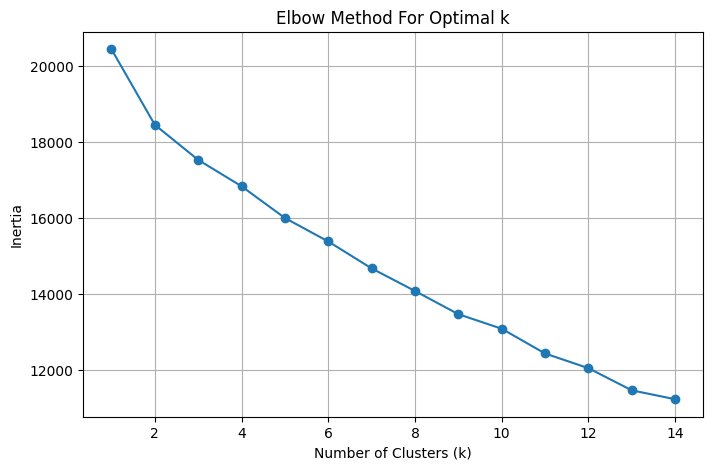

In [7]:
inertia = []
k_range = range(1, 15) # try more values for k
for k in k_range:
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42) # apply kmeans
    kmeans.fit(df_numerical) # fit it to the data
    inertia.append(kmeans.inertia_) # and add the corresponding inertia

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o') # plot the "elbow" obtained
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In the plot, the decrease in inertia is gradual, without a sharp bend.
To avoid Over-Clustering, let us decide that **the results of this plot** say that **values of k from 6 to 12 are good**to  take further into consideration  ,because we want to avoid overclustering.

## Silhouette Score

Measures how well each point fits within its cluster in comparison with others.
The formula is:

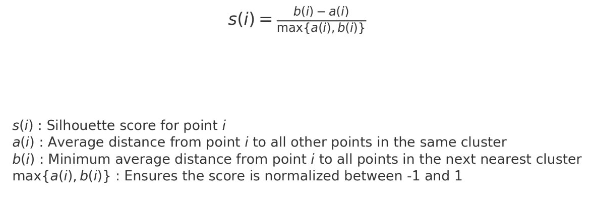

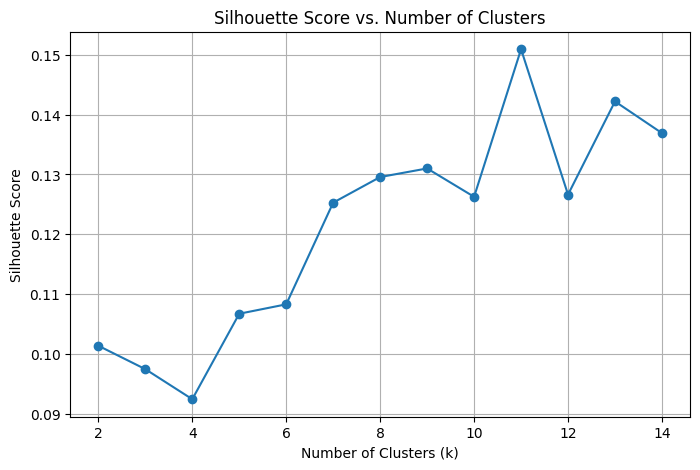

In [8]:
#define range for k
k_range = range(2, 15)  #start from 2
silhouette_scores = []

#loop through different values of k
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_numerical)  #predict cluster assignments
    score = silhouette_score(df_numerical, cluster_labels)  #compute silhouette score
    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.grid()
plt.show()

We can decide that probabily **n=11** is the best choice, because of the Elbow Method + we can see in the last plot that for n=11 the sillhouette score is the highest.

### Fit the K-Means algorithm and label each movie with its cluster.

This is a clustering algorithm that partions data into K non-overlapping groups (clusters) , where each data point belongs to the nearest clster centroid.
The goal is to minimize the distance between data points and their assigned cluster centroids.

Advantages:
- simple and fast.
- scales well to large datasets.
- easy to interpret clusters.

Disadvantages
- assumes spherical clusters of same size
- sensitive to outliers and initialization
- needs to predefine k

How it works:
1. Randomly choose K centroids
2. Assign each point to the nearest centroid
3. Update centroid for each cluster

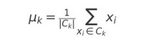

4. Repeat until convergence

In [1]:
kmeans = KMeans(n_clusters=11, n_init=10, random_state=42) 
#choose 11 random clusters and run this initialization 10 times,
# selecting the best based on inertiia

df_numerical["Cluster"] = kmeans.fit_predict(df_numerical)  
#assign datapoints to the nearest centroid   

# 3 & 4 are done automatically by sklearn

#display sample of labeled data
df_numerical.head()

NameError: name 'KMeans' is not defined

### Visualize the clusters in 2D using dimensionality reduction.

Let us see how our clusters look.

**Some imension reduction**
PCA reduces the number of features while keeping most of the dataset's variance.
In our case, we need to plot in 2D, so we restrict our dataset to 2 components.

Let us save into x_scaled all the df_numerical, without df["Clustered"] and then apply PCA.

In [10]:
X_scaled = df_numerical.copy()
X_scaled = X_scaled.drop(columns=["Cluster"])

In [11]:
X_scaled.head()

,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,Adventure,Animation,...,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count
0,-1.614583,-0.716326,-0.985624,4.592377,1.543382,2.463019,-0.672064,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
1,-1.203222,1.735177,1.412753,3.750561,1.043190,2.455505,-0.632888,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818
2,1.219236,1.735177,0.342708,2.908744,1.543382,1.755130,0.431357,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721
3,0.442221,1.735177,0.268911,2.908744,0.126171,2.511623,-0.599939,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048
4,0.396514,-0.716326,0.084421,2.908744,1.543382,2.264344,-0.543821,-0.415987,2.488750,3.923691,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721


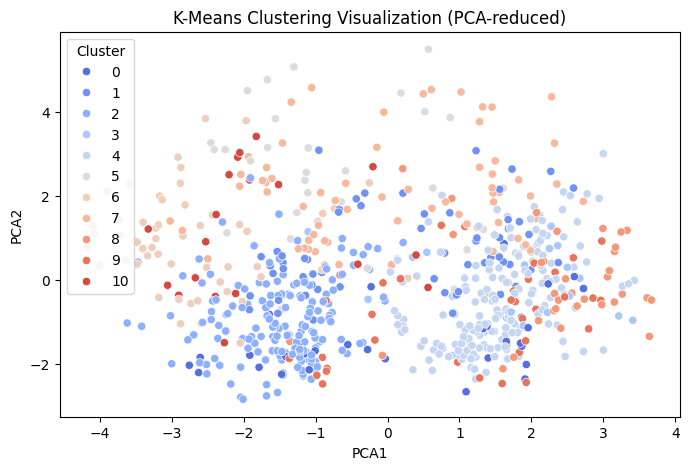

In [12]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df_numerical['PCA1'] = components[:, 0] # splitting into 2 features
df_numerical['PCA2'] = components[:, 1]

# Assuming you have more than 10 clusters, let's create a color palette
n_clusters = len(df_numerical['Cluster'].unique())
colors = sns.color_palette("coolwarm", n_clusters)  # or any other palette

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_numerical, palette=colors)
plt.title("K-Means Clustering Visualization (PCA-reduced)")
plt.show()

We can see that some clusters overlap, but we got some groups (clusters).

### Visualising insights

Let us use the intuited "clusters" from the beginning, to see if they fit the actual clusters found. That way, we can draw some conclusions more easily.

Plotting the financial category

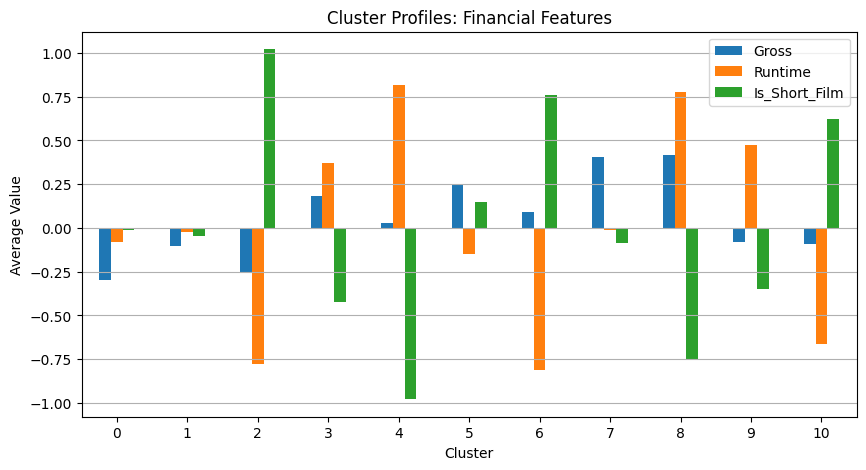

In [13]:
financial_summary = df_financial.groupby(df_numerical["Cluster"]).mean() # group by cluster

#plot financial data
financial_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Cluster Profiles: Financial Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()



We can see that we have some similarities between clusters, even though we can notice some clear different "categories of clusters"
- clusters 0 & 1 are similar
- 2 & 6 & 8 & 10 are similar
- the rest are quite unique

Let us see some clearer differences by using the next intuited cluster, quality.

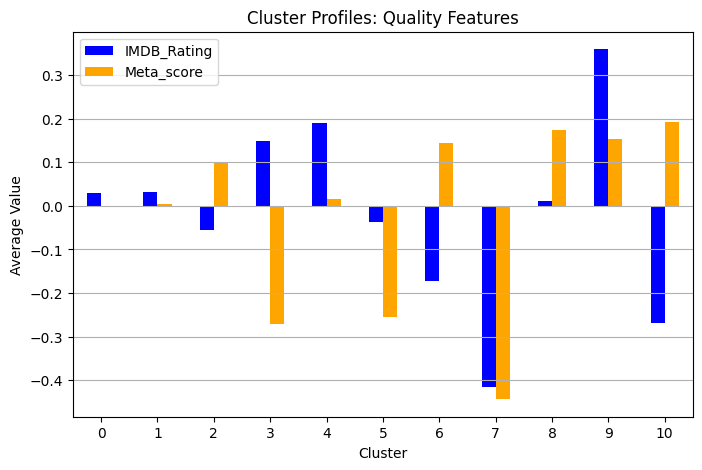

In [14]:
quality_summary = df_quality.groupby(df_numerical["Cluster"]).mean()

quality_summary.plot(kind="bar", figsize=(8, 5), color=["blue", "orange"])
plt.title("Cluster Profiles: Quality Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

- 0 & 1 are, again, similar
- 8 is now different from 2 & 6 & 10
Let us see also the category df_certificate_year.

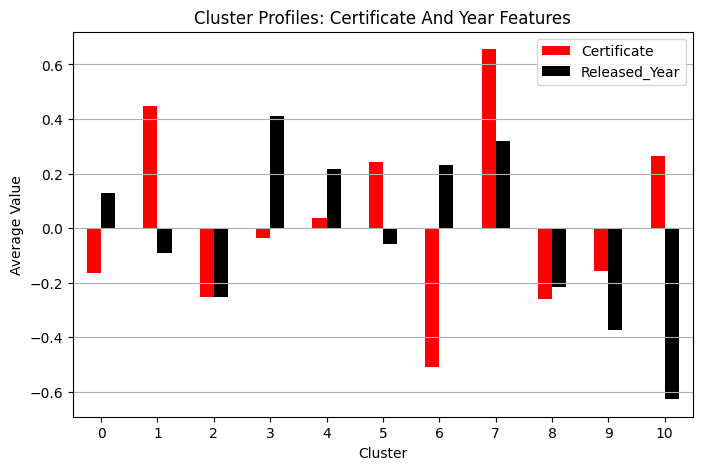

In [15]:
certificate_year_summary = df_certificate_year.groupby(df_numerical["Cluster"]).mean()

certificate_year_summary.plot(kind="bar", figsize=(8, 5), color=["red", "black"])
plt.title("Cluster Profiles: Certificate And Year Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

- 2 & 6 & 10 are now clearly different. So the clustering may ensure uniqueness using these categories.

Let us drop the PCAs, because we only used them for the plots

In [16]:
df_numerical = df_numerical.drop(columns=["PCA1"])
df_numerical = df_numerical.drop(columns=["PCA2"])

## Part 2: Classification with Logistic Regression (Supervised Learning)

Logistic regression outputs a probability (between 0 and 1) by passing the linear combination through a sigmoid function. Classification decision is based on a threshold (usually 0.5).
The sigmoid function is:

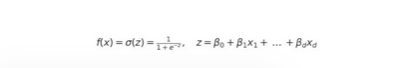

*Loss function* : Binary Cross-Entropy:

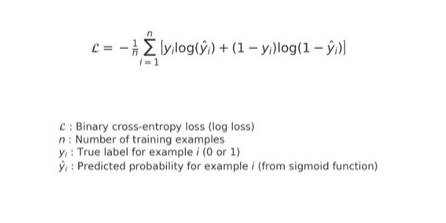

The model tries to MINIMIZE the loss function.

Now we'll build a **Logistic Regression** classifier to predict a binary class (e.g., "Is_Highly_Rated") based on movie features.


**Steps to follow:**

- Create a binary target variable: for example, *Is_Highly_Rated = 1* if IMDB rating >= **the avarage of IMDB rating**, otherwise 0 (but you can select others that you identified relevant in
previous experiments).
- Choose appropriate input features (including feature engineering).
- Split dataset into training and test sets.
- Train a Logistic Regression model.
- Evaluate using accuracy, confusion matrix, precision, recall, and f1-score.
- Interpret the coefficients of the model: what influences movie quality most?

Let us create an *Is_Highly_Rated* feature, because we have engineered other features before( Is_Short_Film , Is_Long_Film, Genre_Count etc..), but now we emphasize more IMDB_Rating, Meta_score etc, so as to see thing from a different perspecive.

In [17]:
df_numerical['Is_Highly_Rated'] = (df_numerical['IMDB_Rating'] >  df_numerical['IMDB_Rating'].median()).astype(int)

Let us see specific correlations for the picked target **Is_Highly_Rated** feature

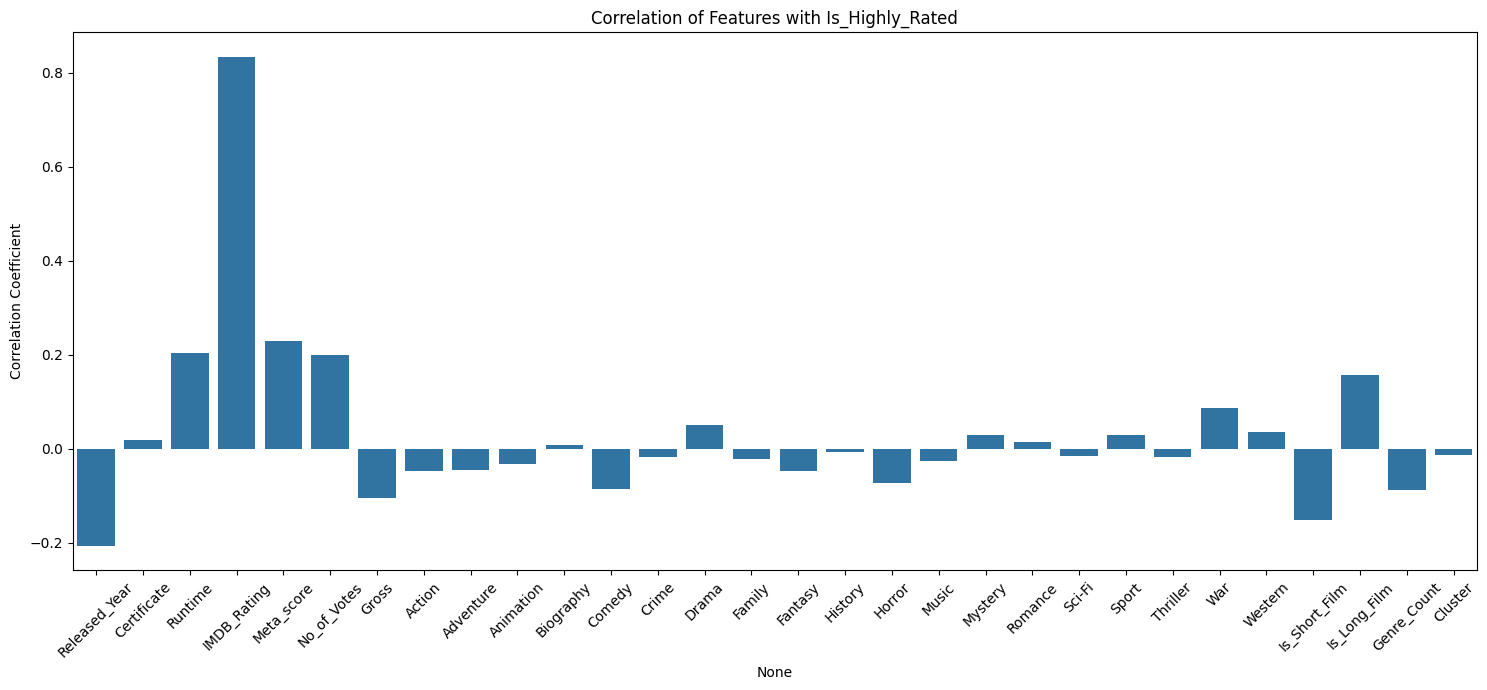

In [18]:
corr_matrix = df_numerical.corr(numeric_only=True)

corr_with_is_highly_rated = corr_matrix['Is_Highly_Rated'].drop('Is_Highly_Rated')  # exclude self-correlation

plt.figure(figsize=(15, 7))
sns.barplot(x=corr_with_is_highly_rated.index, y=corr_with_is_highly_rated.values)
plt.xticks(rotation=45)
plt.title('Correlation of Features with Is_Highly_Rated')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


We can pick those with a correlation bigger that 0.2 (the features will be much more important in predicting the target) and do not take the rest into consideration, because they do not bring any great benefits ( they are not so important to predicting the target, because every feature in this category says very little about the target).

In [19]:
selected_corr_features = corr_with_is_highly_rated[abs(corr_with_is_highly_rated) >= 0.2].index.tolist()
print("Selected based on correlation:", selected_corr_features)

Selected based on correlation: ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes']


let us show the model that we care more about the IMDB_Rating and Meta_score

In [20]:
df_numerical['IMDB_Meta_Product'] = df_numerical['IMDB_Rating'] * df_numerical['Meta_score']

#standardize the new feature
scaler = StandardScaler()
df_numerical['IMDB_Meta_Product'] = scaler.fit_transform(df_numerical[['IMDB_Meta_Product']])


In [21]:
df_numerical.head()

,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,Adventure,Animation,...,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count,Cluster,Is_Highly_Rated,IMDB_Meta_Product
0,-1.614583,-0.716326,-0.985624,4.592377,1.543382,2.463019,-0.672064,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048,2,1,6.479775
1,-1.203222,1.735177,1.412753,3.750561,1.043190,2.455505,-0.632888,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818,4,1,3.443812
2,1.219236,1.735177,0.342708,2.908744,1.543382,1.755130,0.431357,-0.415987,-0.401808,-0.254862,...,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721,1,1,3.995268
3,0.442221,1.735177,0.268911,2.908744,0.126171,2.511623,-0.599939,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048,4,1,0.053790
4,0.396514,-0.716326,0.084421,2.908744,1.543382,2.264344,-0.543821,-0.415987,2.488750,3.923691,...,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721,6,1,3.995268


Let us save the selected feature & target in a new dataset, so we can work with it.

In [22]:
df_selected = df_numerical[["Released_Year","Runtime","IMDB_Rating","Meta_score","No_of_Votes","IMDB_Meta_Product","Is_Highly_Rated"]].copy()
df_selected.head()

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,IMDB_Meta_Product,Is_Highly_Rated
0,-1.614583,-0.985624,4.592377,1.543382,2.463019,6.479775,1
1,-1.203222,1.412753,3.750561,1.043190,2.455505,3.443812,1
2,1.219236,0.342708,2.908744,1.543382,1.755130,3.995268,1
3,0.442221,0.268911,2.908744,0.126171,2.511623,0.053790,1
4,0.396514,0.084421,2.908744,1.543382,2.264344,3.995268,1


We can see that the target is well-distributed along the dataset, because we have more low-rated films than high-rated (expected thing).

In [23]:
df_selected['Is_Highly_Rated'].value_counts()

Is_Highly_Rated
0    414
1    291
Name: count, dtype: int64

### Split dataset into training and test sets. Train a Logistic Regression model.

In [24]:
X = df_selected[["Released_Year","Runtime","IMDB_Rating","Meta_score","No_of_Votes","IMDB_Meta_Product"]]
y = df_selected['Is_Highly_Rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # splitting into train & test sets

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

We have trained our model. Let use see some useful metrics to determine the quality of the model.

### Evaluate using accuracy, confusion matrix, precision, recall, and f1-score.

## Logistic Regression Evaluation Metrics
- **Accuracy**: Proportion of correctly predicted instances.
- **Precision**: Proportion of predicted positives that are actually positive.
- **Recall**: Proportion of actual positives that were correctly predicted.
- **F1 Score**: Harmonic mean of precision and recall.
- **Confusion Matrix**: Summarizes prediction results.

### Evaluation Metric Formulas:
- Accuracy:
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

- Precision:
$$ \text{Precision} = \frac{TP}{TP + FP} $$

- Recall:
$$ \text{Recall} = \frac{TP}{TP + FN} $$

- F1 Score:
$$ \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

Where:
- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives


In [25]:
# accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 1.00


In [26]:
print(f"Precision: {precision_score(y_test, y_pred):.2f}") # other metrics
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
[[75  0]
 [ 0 66]]


This is not good. Our model overfits the dataset and only memorizes the way the label is done, without actually learning. This is because **IMDB_Rating** is **100%** related to **Is_Highly_Rated** + also the engineered feature **IMDB_Meta_Product** is produced using **IMDB_Rating**.

So let us try to remove them both and engineer a new feature similar to how we produced **IMDB_Meta_Product**, but use **R_Y** & **Meta_score** this time.

In [27]:
df_selected = df_selected[["Released_Year","Runtime","Meta_score","No_of_Votes","Is_Highly_Rated"]].copy()

In [28]:
df_selected['RY_Meta_score'] = df_selected['Released_Year'] * df_numerical['Meta_score'] # pick these because they have
               # the biggest correlation with target value

#standardize the new feature
scaler = StandardScaler()
df_selected['RY_Meta_score'] = scaler.fit_transform(df_selected[['RY_Meta_score']])

In [29]:
df_selected.head()

,Released_Year,Runtime,Meta_score,No_of_Votes,Is_Highly_Rated,RY_Meta_score
0,-1.614583,-0.985624,1.543382,2.463019,1,-2.212225
1,-1.203222,1.412753,1.043190,2.455505,1,-0.974565
2,1.219236,0.342708,1.543382,1.755130,1,2.164733
3,0.442221,0.268911,0.126171,2.511623,1,0.337408
4,0.396514,0.084421,1.543382,2.264344,1,0.894004


Now let us retrain the model and see the metrics.

In [30]:
X = df_selected[["Released_Year","Runtime","Meta_score","No_of_Votes","RY_Meta_score"]]
y = df_selected['Is_Highly_Rated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # splitting into train & test sets

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}") # other metrics
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.62
Precision: 0.64
Recall: 0.45
F1 Score: 0.53
Confusion Matrix:
[[58 17]
 [36 30]]


The results are more realistic now.

Is_Highly_Rated has more 0s that 1s, and that is why we have so many false positives in the confusion matrix.
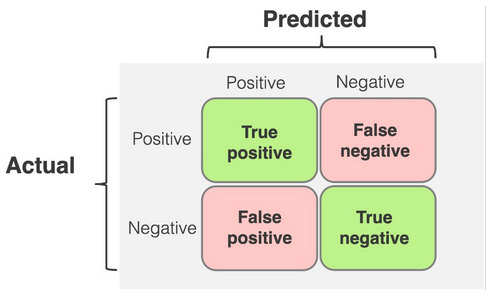

### Interpreting coefficients of the model

How to Interpret Coefficients?
- Positive Coefficient (β > 0) → Increases the chance of a high rating.
- Negative Coefficient (β < 0) → Decreases the chance of a high rating.
- Magnitude (absolute value of β) → Shows the strength of the impact.

In [31]:
#get feature names
feature_names = X_train.columns

#extract coefficients
coefficients = model.coef_[0]  # Logistic regression returns a nested list

#create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

#sort by absolute value to see most important factors
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

#display results
print(coef_df)

         Feature  Coefficient
3    No_of_Votes     0.625616
0  Released_Year    -0.555452
1        Runtime     0.488455
2     Meta_score     0.483328
4  RY_Meta_score    -0.032128


We can see that the No_of_Votes clearly increase the chance of a higher quality, which is somehow expected, but I expected Meta_score to have more influence. Also Runtime has a positive influence -> longer movies require more bidget, so they are probably more qualitative.

The year is a strong negative coefficient , this is expected -> technology has evolved and now movies are more qualitative.
The engineered feature is not that strong, this is expected, because it is a combination of two already strongly predictive features, it may not add much new information to the model.

## Part 3: Reflection and Insights

- Compare insights from clustering and classification. Was any of the groups more relevant than others?
- Suggest improvements or future directions.

For the Clustering, we my intuition from the beginning was good, as I managed to separate already in some clusters, which helped me analize the clusteres provided by the algorithm, which were numerous (11) and find some differences between them. The disadvantage is that some clusters overlap in some parts. We could use Gaussian Mixture Models (GMM), because it handles well overlapping clusters.

Another variant would be having some domain knowledge, so as to actually know how many clusters we need.

Classification gave us good results, but the problem was that the threshold is at 50% for Is_Highly_Rated, and this gave us many values of 0's and a few values of 1's. For the future, we can either change the threshold (which would mean changing the requirement in a real life problem -> not so suitable) or being provided more data with good, highly-rated movies.

## Bonus Challenge

- Try a different clustering algorithm.
- Train a more complex classifier and compare results.

### GMM model

Choosing the Optimal Number of Clusters
Instead of using the Elbow Method like K-Means, GMM uses Bayesian Information Criterion (BIC) or Akaike Information Criterion (AIC) to determine the best number of clusters.

In [32]:
df_numerical.head()

,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,Adventure,Animation,...,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count,Cluster,Is_Highly_Rated,IMDB_Meta_Product
0,-1.614583,-0.716326,-0.985624,4.592377,1.543382,2.463019,-0.672064,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048,2,1,6.479775
1,-1.203222,1.735177,1.412753,3.750561,1.043190,2.455505,-0.632888,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818,4,1,3.443812
2,1.219236,1.735177,0.342708,2.908744,1.543382,1.755130,0.431357,-0.415987,-0.401808,-0.254862,...,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721,1,1,3.995268
3,0.442221,1.735177,0.268911,2.908744,0.126171,2.511623,-0.599939,-0.415987,-0.401808,-0.254862,...,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048,4,1,0.053790
4,0.396514,-0.716326,0.084421,2.908744,1.543382,2.264344,-0.543821,-0.415987,2.488750,3.923691,...,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721,6,1,3.995268


In [33]:

df_numerical = df_numerical.drop(columns=["IMDB_Meta_Product"])
df_numerical = df_numerical.drop(columns=["Is_Highly_Rated"])
df_numerical = df_numerical.drop(columns=["Cluster"])

In [34]:
df_numerical.head()

,Released_Year,Certificate,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Action,Adventure,Animation,...,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western,Is_Short_Film,Is_Long_Film,Genre_Count
0,-1.614583,-0.716326,-0.985624,4.592377,1.543382,2.463019,-0.672064,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,1.021508,-0.987314,-0.665048
1,-1.203222,1.735177,1.412753,3.750561,1.043190,2.455505,-0.632888,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,6.782330,-0.978945,1.012848,-2.068818
2,1.219236,1.735177,0.342708,2.908744,1.543382,1.755130,0.431357,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,2.533980,-0.228558,-0.147442,-0.978945,1.012848,0.738721
3,0.442221,1.735177,0.268911,2.908744,0.126171,2.511623,-0.599939,-0.415987,-0.401808,-0.254862,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,-0.665048
4,0.396514,-0.716326,0.084421,2.908744,1.543382,2.264344,-0.543821,-0.415987,2.488750,3.923691,...,-0.345033,-0.406558,-0.235349,-0.161867,-0.394636,-0.228558,-0.147442,-0.978945,1.012848,0.738721


Now we have our data prepared for the clustering (we removed past podifications to the dataset)

AIC estimates how well a model fits the data while adding a penalty for complexity (too many parameters). It helps balance model accuracy and simplicity.
BIC is similar to AIC but applies a stronger penalty for complexity when the dataset size is large. It is derived from Bayesian probability theory and is often preferred for model selection.

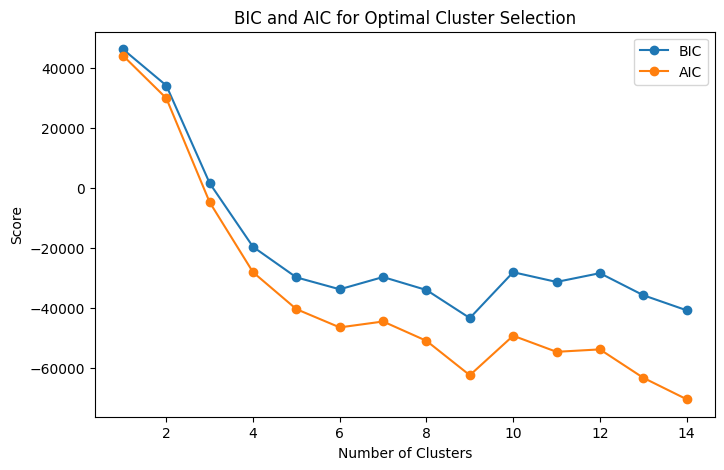

In [35]:
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
n_clusters_range = range(1, 15)
for n in n_clusters_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(df_numerical)
    bic_scores.append(gmm.bic(df_numerical))
    aic_scores.append(gmm.aic(df_numerical))

# Plot BIC & AIC to find the optimal number of clusters
plt.figure(figsize=(8, 5))
plt.plot(n_clusters_range, bic_scores, label='BIC', marker='o')
plt.plot(n_clusters_range, aic_scores, label='AIC', marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.legend()
plt.title("BIC and AIC for Optimal Cluster Selection")
plt.show()


The lowest BIC or AIC score suggests the optimal number of clusters. Both BIC (blue line) and AIC (orange line) decrease rapidly from 1 to around 6 clusters.After 6 clusters, the decrease slows down and fluctuates.
AIC keeps decreasing, but BIC stabilizes and fluctuates around 6-8 clusters.
So let us choose 6 clusters.

How Does GMM Work?

GMM assumes that your data consists of a mixture of multiple Gaussian distributions. The algorithm identifies these distributions and assigns each point a probability of belonging to each cluster.

Steps in GMM:

-️ Initialize K Gaussian Distributions (each cluster has its own mean & variance).

️- Expectation Step (E-step):

        Calculate the probability that each data point belongs to each Gaussian distribution using the Probability Density Function (PDF).
        
        - Maximization Step (M-step):

        Update the parameters (mean, variance, and weight) of the Gaussians to maximize the likelihood of the data given the model.
        
        - Repeat Steps 2 & 3 until convergence (when the parameters stop changing significantly).

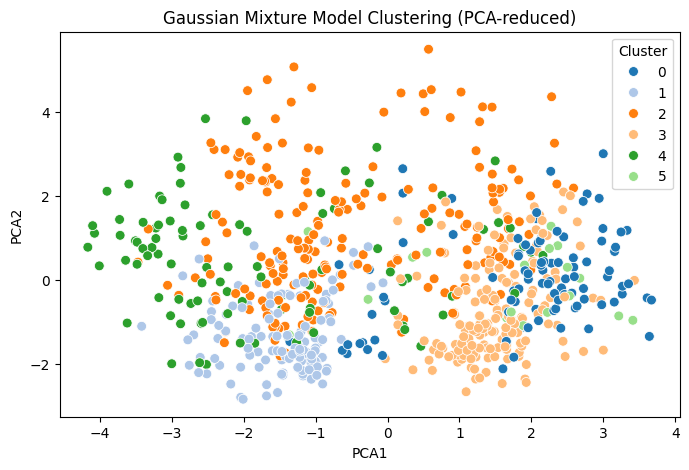

In [36]:
# Fit Gaussian Mixture Model with 6 clusters
gmm = GaussianMixture(n_components=6, random_state=42)
gmm.fit(df_numerical)

# Predict Cluster Labels
clusters = gmm.predict(df_numerical)

# Add Cluster Labels to DataFrame
df_numerical['Cluster'] = clusters

# PCA for 2D visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df_numerical['PCA1'] = components[:, 0]
df_numerical['PCA2'] = components[:, 1]

# Choosing a color palette based on the number of clusters
n_clusters = df_numerical['Cluster'].nunique()
palette = sns.color_palette("tab20", n_clusters) 

# GMM Clustering Visualization in PCA space
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_numerical, palette=palette, s=50)
plt.title("Gaussian Mixture Model Clustering (PCA-reduced)")
plt.show()


We can see that now the categories are a bit better separated.

### Classifying with Random Forest

The explanation of how Random Forests work are given in Regression Models Comparison Project.

In [39]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(  
    n_estimators=100,       
    max_depth=4,  # choose simpler trees, less likely to overfit          
    random_state=1)

rf.fit(X_train, y_train) 
rf_preds = rf.predict(X_test)

In [41]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.2f}")
print(f"Precision: {precision_score(y_test, rf_preds):.2f}") # other metrics
print(f"Recall: {recall_score(y_test, rf_preds):.2f}")
print(f"F1 Score: {f1_score(y_test, rf_preds):.2f}")
print("Confusion Matrix RF:")
print(confusion_matrix(y_test, rf_preds))

Random Forest Accuracy: 0.67
Precision: 0.76
Recall: 0.42
F1 Score: 0.54
Confusion Matrix RF:
[[66  9]
 [38 28]]


In [43]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}") # other metrics
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix Logistic Regression:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.62
Precision: 0.64
Recall: 0.45
F1 Score: 0.53
Confusion Matrix Logistic Regression:
[[58 17]
 [36 30]]


The random forest performs better and this is normal, because it is much complex than the Logistic regression. Somehow, the RF amplifizes the difference between the 0's and 1's in the false positive size, because this disatvantage of the dataset is used by more trees that "learn" in a similar wrong way.

At least the false negatives are much smaller.